In [1]:
%load_ext autoreload
%autoreload 2

In [39]:
import diabetes_prediction.function as function
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

In [21]:
train_data = function.load_train_data()
X_train = train_data['X_train']
y_train = train_data['y_train']
X_test = train_data['X_test']
y_test = train_data['y_test']

loading train data...
train data loaded!


In [15]:
models = function.load_models()

loading models...
all models loaded!


### logistic_regression

In [23]:
lr_y_pred = models['logistic_regression'].predict(X_test)
lr_prob = models['logistic_regression'].predict_proba(X_test)[:,1]
print(classification_report(y_test, lr_y_pred))
print(confusion_matrix(y_test, lr_y_pred))
print("roc_auc_score:",roc_auc_score(y_test, lr_prob))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     17530
           1       0.86      0.64      0.73      1696

    accuracy                           0.96     19226
   macro avg       0.91      0.81      0.85     19226
weighted avg       0.96      0.96      0.96     19226

[[17352   178]
 [  614  1082]]
roc_auc_score: 0.9595212957033226


In [25]:
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coef': models['logistic_regression'].coef_[0]
}).sort_values('coef', ascending=False)

display(coef_df)

,feature,coef
4,HbA1c_level,2.510446
5,blood_glucose_level,1.369120
0,age,1.080888
1,hypertension,0.733852
2,heart_disease,0.702337
7,smoking_history_current,0.619642
3,bmi,0.600550
9,smoking_history_former,0.521432
8,smoking_history_ever,0.496899
10,smoking_history_never,0.492927


In [26]:
y_pred_03 = (lr_prob >= 0.3).astype(int)
y_pred_04 = (lr_prob >= 0.4).astype(int)
y_pred_06 = (lr_prob >= 0.6).astype(int)

for t in [0.3, 0.4, 0.5, 0.6]:
    
    y_pred = (lr_prob >= t).astype(int)
    
    print(f"\nThreshold = {t}")
    
    print(classification_report(
        y_test,
        y_pred,
        digits=3
    ))


Threshold = 0.3
              precision    recall  f1-score   support

           0      0.972     0.971     0.972     17530
           1      0.707     0.715     0.711      1696

    accuracy                          0.949     19226
   macro avg      0.840     0.843     0.841     19226
weighted avg      0.949     0.949     0.949     19226


Threshold = 0.4
              precision    recall  f1-score   support

           0      0.968     0.982     0.975     17530
           1      0.785     0.669     0.722      1696

    accuracy                          0.955     19226
   macro avg      0.877     0.825     0.849     19226
weighted avg      0.952     0.955     0.953     19226


Threshold = 0.5
              precision    recall  f1-score   support

           0      0.966     0.990     0.978     17530
           1      0.859     0.638     0.732      1696

    accuracy                          0.959     19226
   macro avg      0.912     0.814     0.855     19226
weighted avg      0.956

In [28]:
from sklearn.metrics import f1_score

best_t = 0
best_f1 = 0

for t in np.arange(0.1,0.9,0.01):
    
    y_pred = (lr_prob >= t).astype(int)
    
    f1 = f1_score(y_test,y_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(best_t,best_f1)

0.4899999999999998 0.7333333333333333


### random_forest

In [29]:
rf_y_pred = models['random_forest'].predict(X_test)

rf_prob = models['random_forest'].predict_proba(X_test)[:,1]

In [30]:
print(classification_report(y_test, rf_y_pred))

print(confusion_matrix(y_test, rf_y_pred))

print(
    roc_auc_score(
        y_test,
        rf_prob
    )
)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17530
           1       0.94      0.70      0.80      1696

    accuracy                           0.97     19226
   macro avg       0.96      0.85      0.89     19226
weighted avg       0.97      0.97      0.97     19226

[[17457    73]
 [  513  1183]]
0.9569078177302521


In [31]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': models['random_forest'].feature_importances_
})

importance_df = importance_df.sort_values(
    'importance',
    ascending=False
)

display(importance_df)

,feature,importance
4,HbA1c_level,0.398297
5,blood_glucose_level,0.322469
3,bmi,0.121035
0,age,0.103198
1,hypertension,0.016941
2,heart_disease,0.010391
6,gender_Male,0.007052
10,smoking_history_never,0.005721
9,smoking_history_former,0.004739
7,smoking_history_current,0.003841


In [ ]:
# compare if remove unrelevant columns
selected_features = [
    'HbA1c_level',
    'blood_glucose_level',
    'bmi',
    'age'
]

In [34]:
tuned_rf_y_pred = models['tuned_random_forest'].predict(X_test)

tuned_rf_prob = models['tuned_random_forest'].predict_proba(X_test)[:,1]

print(classification_report(y_test, tuned_rf_y_pred))
print("roc_auc_score:",roc_auc_score(y_test, tuned_rf_prob))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17530
           1       0.99      0.69      0.81      1696

    accuracy                           0.97     19226
   macro avg       0.98      0.84      0.90     19226
weighted avg       0.97      0.97      0.97     19226

roc_auc_score: 0.9727133371094296


### xgboost

In [35]:
xgb_y_pred = models['xgboost'].predict(X_test)

xgb_prob = models['xgboost'].predict_proba(X_test)[:, 1]

print(classification_report(y_test, xgb_y_pred))
print("roc_auc_score:",roc_auc_score(y_test, xgb_prob))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17530
           1       0.95      0.70      0.81      1696

    accuracy                           0.97     19226
   macro avg       0.96      0.85      0.90     19226
weighted avg       0.97      0.97      0.97     19226

roc_auc_score: 0.975440568863081


### conclusion

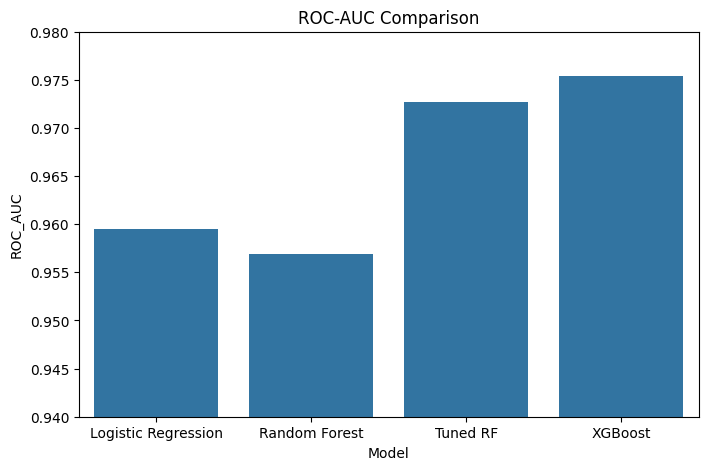

In [38]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Tuned RF',
        'XGBoost'
    ],
    'ROC_AUC': [
        0.9595,
        0.9569,
        0.9727,
        0.9754
    ]
})

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='ROC_AUC'
)

plt.title('ROC-AUC Comparison')
plt.ylim(0.94, 0.98)

plt.show()

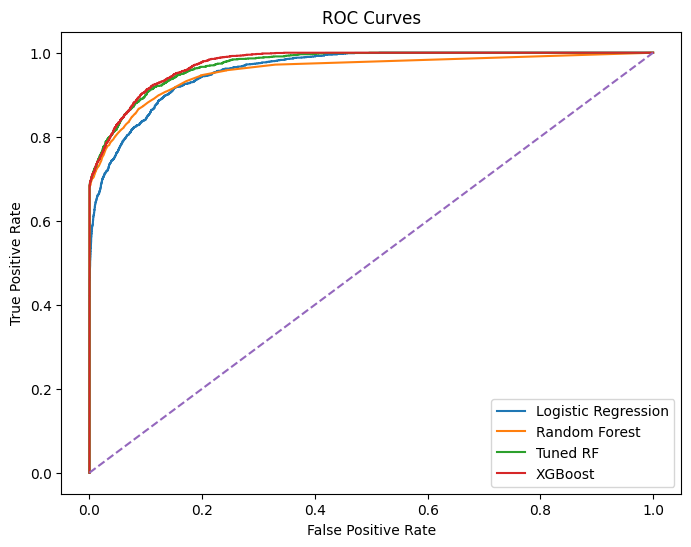

In [40]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

fpr_tuned, tpr_tuned, _ = roc_curve(y_test, tuned_rf_prob)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label='Logistic Regression'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label='Random Forest'
)

plt.plot(
    fpr_tuned,
    tpr_tuned,
    label='Tuned RF'
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label='XGBoost'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curves')

plt.legend()

plt.show()

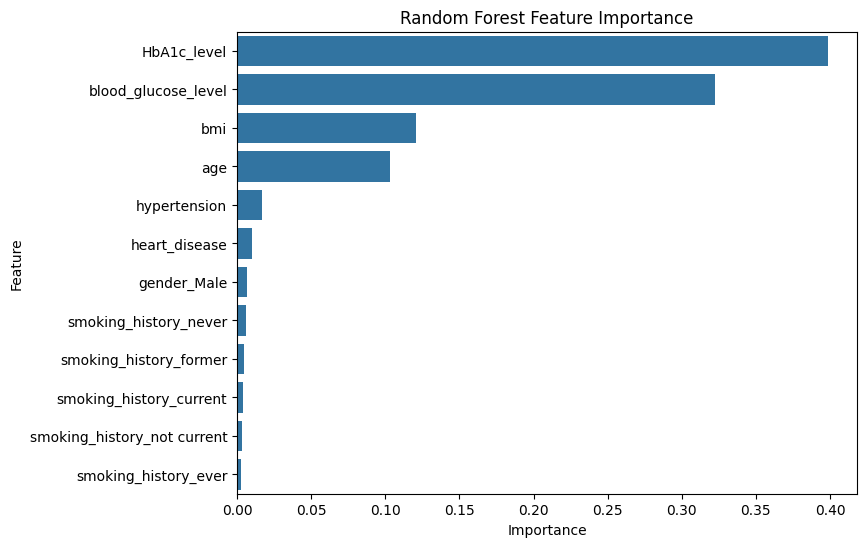

In [41]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': models['random_forest'].feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        'Importance',
        ascending=False
    )
)

plt.figure(figsize=(8,6))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature'
)

plt.title(
    'Random Forest Feature Importance'
)

plt.show()